# Phase 1 — Training a volume regressor (proper ML workflow)

`00_feasibility.ipynb` showed that the **idea** works: `volume ≈ k · area · height`
with `k ≈ 0.51` reaches ~24 % MAPE on cross-validation. That single-parameter
baseline is what the app currently ships.

This notebook does the **real ML training**:

1. **Richer feature engineering** — shape descriptors (circularity, solidity, aspect
   ratio, …) per item, not just area and height.
2. **Train / Validation / Test split** — the test set is touched **once** at the end.
3. **Multiple model families** — RidgeCV, Lasso, Random Forest, Gradient Boosting, MLP.
4. **Hyperparameter tuning** via `GridSearchCV` on the validation folds.
5. **Learning curves** — does the model need more data?
6. **Permutation importance** — which features actually carry the signal?
7. **Final evaluation** on the held-out test set with the chosen model.
8. **Persist** the trained model alongside the shipped `proportional` baseline.

Why this matters: a one-parameter model isn't really *learning* much. With more
features and proper tuning we can see whether a richer model genuinely beats the
physics baseline, or whether the 1-parameter form already extracts everything the
data has to offer (a real finding either way).

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from foodvol import config, benchmark
from foodvol.volume import VolumeEstimator, evaluate

RANDOM_SEED = 0
print("compute device:", config.get_device())

compute device: mps


## 1. Load the extended feature table

`extract_features_extended` runs FastSAM once per portion to compute, for **top and
side masks**, both metric measurements (area, height) and **scale-invariant shape
descriptors**:

* **aspect_ratio** — bounding-box width / height
* **circularity** — 4·π·area / perim² (1.0 = perfect circle)
* **solidity** — area / convex-hull area (porous = low)
* **extent** — area / bounding-box area
* **elongation** — `1 − minor/major` of the fitted ellipse

These let a regressor distinguish a round apple from a long banana from a flat
slice — information that the physics baseline `0.5·A·h` simply cannot use.

In [2]:
df = benchmark.extract_features_extended(use_cache=True, progress=False)
print(f"{len(df)} portions × {df.shape[1]} columns\n")
display(df.head(3))
df[["area_cm2","height_cm","top_circ","top_solidity","top_elong","side_aspect","volume_ml"]].describe().round(2)

145 portions × 18 columns



,portion_id,food_type,area_cm2,height_cm,side_area_cm2,top_aspect,top_circ,top_solidity,top_extent,top_elong,side_aspect,side_circ,side_solidity,side_extent,side_elong,volume_ml,weight_g,density_g_per_ml
0,apple001,apple,72.234,7.669,60.974,1.0221,0.2413,0.8739,0.8290,0.0686,1.2210,0.3789,0.9323,0.8354,0.2378,310.0,244.5,0.7887
1,apple002,apple,63.708,7.368,47.201,0.9667,0.8936,0.9953,0.7781,0.0448,1.0685,0.7576,0.9848,0.8044,0.0687,290.0,232.5,0.8017
2,apple003,apple,65.531,6.786,40.405,0.9665,0.8124,0.9839,0.7958,0.0259,1.0671,0.8527,0.9893,0.8253,0.0553,280.0,219.0,0.7821


,area_cm2,height_cm,top_circ,top_solidity,top_elong,side_aspect,volume_ml
count,145.00,145.00,145.00,145.00,145.00,145.00,145.00
mean,62.57,4.99,0.63,0.94,0.20,1.91,172.76
std,33.02,1.79,0.19,0.09,0.16,1.26,89.58
min,2.77,0.86,0.06,0.39,0.01,0.64,30.00
25%,37.25,3.41,0.50,0.94,0.08,1.09,100.00
50%,58.24,4.68,0.66,0.97,0.16,1.26,170.00
75%,78.08,6.53,0.78,0.99,0.29,2.25,220.00
max,200.53,10.15,0.89,1.00,0.68,7.16,450.00


## 2. Train / Validation / Test split (stratified by food type)

In [3]:
from sklearn.model_selection import train_test_split

# Stratify by food type so every class is represented in train/val/test where possible.
# Tiny classes (n=2 like 'grape') can fail stratification; drop them from the strata key.
strata = df.food_type.where(df.food_type.map(df.food_type.value_counts()) >= 3, other="_rare")

df_trainval, df_test = train_test_split(df, test_size=0.15, random_state=RANDOM_SEED,
                                        stratify=strata)
strata_tv = strata.loc[df_trainval.index]
df_train, df_val = train_test_split(df_trainval, test_size=0.176,   # 0.176 of 85% ≈ 15% of total
                                    random_state=RANDOM_SEED, stratify=strata_tv)

print(f"train: {len(df_train)} | val: {len(df_val)} | test: {len(df_test)} "
      f"(total {len(df)})")
print("\nclass coverage:")
counts = pd.DataFrame({
    "train": df_train.food_type.value_counts(),
    "val":   df_val.food_type.value_counts(),
    "test":  df_test.food_type.value_counts(),
}).fillna(0).astype(int)
counts

train: 101 | val: 22 | test: 22 (total 145)

class coverage:


,train,val,test
food_type,,,
apple,13,3,3
banana,11,2,2
bread,5,1,1
bun,6,1,1
doughnut,7,1,1
egg,4,1,1
fired_dough_twist,5,1,1
grape,2,0,0
lemon,2,1,1


## 3. Feature sets

We compare **two feature sets** to see whether the extra shape descriptors actually
help:

* **base** — just `area_cm2`, `height_cm`, `area · height` (what the baseline uses)
* **extended** — base + 10 shape descriptors from top and side

In [4]:
BASE_FEATURES = ["area_cm2", "height_cm"]
EXTRA_FEATURES = ["side_area_cm2",
                  "top_aspect", "top_circ", "top_solidity", "top_extent", "top_elong",
                  "side_aspect", "side_circ", "side_solidity", "side_extent", "side_elong"]

def make_xy(frame, features):
    X = frame[features].copy()
    X["area_x_height"] = frame.area_cm2 * frame.height_cm   # the physically dominant term
    return X.to_numpy(), frame.volume_ml.to_numpy()

X_train_base, y_train = make_xy(df_train, BASE_FEATURES)
X_val_base,   y_val   = make_xy(df_val,   BASE_FEATURES)
X_test_base,  y_test  = make_xy(df_test,  BASE_FEATURES)

X_train_ext, _ = make_xy(df_train, BASE_FEATURES + EXTRA_FEATURES)
X_val_ext,   _ = make_xy(df_val,   BASE_FEATURES + EXTRA_FEATURES)
X_test_ext,  _ = make_xy(df_test,  BASE_FEATURES + EXTRA_FEATURES)

print(f"base feature matrix:     {X_train_base.shape}  ({BASE_FEATURES + ['area_x_height']})")
print(f"extended feature matrix: {X_train_ext.shape}")

base feature matrix:     (101, 3)  (['area_cm2', 'height_cm', 'area_x_height'])
extended feature matrix: (101, 14)


## 4. Hyperparameter search — five model families

Each model is wrapped in a `Pipeline(StandardScaler → estimator)` and tuned with
`GridSearchCV(cv=5)` on the **training** data. The validation set is then used to
pick between feature sets and model families. The test set is not touched yet.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import RidgeCV, Lasso, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

def pipe(est):
    return Pipeline([("scaler", StandardScaler()), ("est", est)])

GRIDS = {
    "Ridge":   (pipe(RidgeCV(alphas=np.logspace(-3, 3, 13))), {}),
    "Lasso":   (pipe(Lasso(max_iter=20000)),
                {"est__alpha": [0.01, 0.1, 1.0, 10.0]}),
    "Huber":   (pipe(HuberRegressor(max_iter=2000)),
                {"est__alpha": [0.0001, 0.001, 0.01],
                 "est__epsilon": [1.35, 1.75, 2.0]}),
    "RandomForest": (pipe(RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)),
                {"est__n_estimators": [200, 400],
                 "est__max_depth": [None, 4, 8],
                 "est__min_samples_leaf": [1, 2, 4]}),
    "GradientBoosting": (pipe(GradientBoostingRegressor(random_state=RANDOM_SEED)),
                {"est__n_estimators": [200, 400],
                 "est__max_depth": [2, 3, 4],
                 "est__learning_rate": [0.03, 0.06, 0.1]}),
    "MLP":     (pipe(MLPRegressor(random_state=RANDOM_SEED, max_iter=2000, early_stopping=True)),
                {"est__hidden_layer_sizes": [(16,), (32,), (16, 8)],
                 "est__alpha": [0.0001, 0.001, 0.01]}),
}


def tune_and_eval(name, est, grid, X_tr, y_tr, X_va, y_va):
    gs = GridSearchCV(est, grid, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
    gs.fit(X_tr, y_tr)
    val_pred = np.clip(gs.predict(X_va), 0, None)
    m = evaluate(y_va, val_pred)
    return {"model": name, "best_params": gs.best_params_,
            "val_MAPE": m["MAPE_percent"], "val_R2": m["R2"], "val_MAE": m["MAE"],
            "estimator": gs.best_estimator_}

In [6]:
results = []
for feat_name, X_tr, X_va in [("base", X_train_base, X_val_base),
                              ("extended", X_train_ext, X_val_ext)]:
    for model_name, (est, grid) in GRIDS.items():
        r = tune_and_eval(model_name, est, grid, X_tr, y_train, X_va, y_val)
        r["features"] = feat_name
        results.append(r)

# Physics baseline (no fit) for reference.
phys_val = 0.5 * df_val.area_cm2.values * df_val.height_cm.values
m = evaluate(y_val, phys_val)
results.append({"model": "physics (0.5·A·h)", "features": "—", "best_params": "—",
                "val_MAPE": m["MAPE_percent"], "val_R2": m["R2"], "val_MAE": m["MAE"],
                "estimator": None})

# Trained 'proportional' baseline (single param k learned from train).
ah = df_train.area_cm2.values * df_train.height_cm.values
k_learned = float(np.sum(ah * y_train) / np.sum(ah * ah))
prop_val = k_learned * df_val.area_cm2.values * df_val.height_cm.values
m = evaluate(y_val, prop_val)
results.append({"model": "proportional (1 param)", "features": "base", "best_params": f"k={k_learned:.4f}",
                "val_MAPE": m["MAPE_percent"], "val_R2": m["R2"], "val_MAE": m["MAE"],
                "estimator": None})

leaderboard = (pd.DataFrame(results)
               .sort_values("val_MAPE")
               .reset_index(drop=True)
               .drop(columns=["estimator"]))
leaderboard.round(2)

,model,best_params,val_MAPE,val_R2,val_MAE,features
0,GradientBoosting,"{'est__learning_rate': 0.03, 'est__max_depth':...",13.80,0.93,18.96,base
1,RandomForest,"{'est__max_depth': 4, 'est__min_samples_leaf':...",14.05,0.92,21.44,base
2,RandomForest,"{'est__max_depth': None, 'est__min_samples_lea...",16.05,0.89,23.89,extended
3,GradientBoosting,"{'est__learning_rate': 0.06, 'est__max_depth':...",18.10,0.92,21.73,extended
4,Huber,"{'est__alpha': 0.01, 'est__epsilon': 2.0}",21.11,0.85,27.49,extended
5,Lasso,{'est__alpha': 1.0},25.71,0.83,31.02,extended
6,proportional (1 param),k=0.5073,26.03,0.73,38.27,base
7,physics (0.5·A·h),—,26.57,0.72,39.65,—
8,MLP,"{'est__alpha': 0.0001, 'est__hidden_layer_size...",27.74,0.68,38.67,extended
9,Huber,"{'est__alpha': 0.01, 'est__epsilon': 1.35}",27.93,0.79,35.24,base


## 5. Visual comparison of the leaderboard

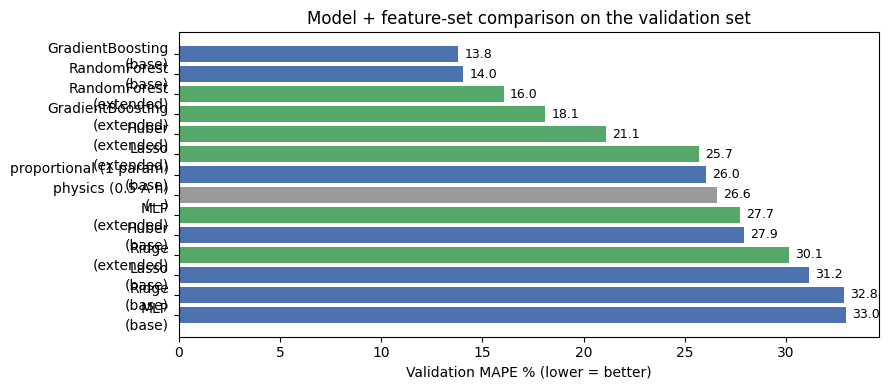

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
order = leaderboard.sort_values("val_MAPE")
colors = ["#55A868" if f == "extended" else "#4C72B0" if f == "base" else "#999"
          for f in order.features]
labels = [f"{m}\n({f})" for m, f in zip(order.model, order.features)]
ax.barh(labels[::-1], order.val_MAPE.values[::-1], color=colors[::-1])
for i, v in enumerate(order.val_MAPE.values[::-1]):
    ax.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=9)
ax.set(xlabel="Validation MAPE % (lower = better)",
       title="Model + feature-set comparison on the validation set")
plt.tight_layout(); plt.show()

## 6. Pick the winner and inspect it

We choose the row with the lowest validation MAPE among the *fitted* models. The
test set has **not** been used yet — its only job is the final sanity check.

In [8]:
winner_row = next(r for r in results if r["estimator"] is not None and
                  r["val_MAPE"] == min(r["val_MAPE"] for r in results
                                       if r["estimator"] is not None))
print(f"WINNER: {winner_row['model']} on {winner_row['features']} features")
print(f"  val MAPE: {winner_row['val_MAPE']:.2f}%   val R²: {winner_row['val_R2']:.2f}")
print(f"  best params: {winner_row['best_params']}")

best_estimator = winner_row["estimator"]
best_features = BASE_FEATURES + (EXTRA_FEATURES if winner_row["features"] == "extended" else [])

WINNER: GradientBoosting on base features
  val MAPE: 13.80%   val R²: 0.93
  best params: {'est__learning_rate': 0.03, 'est__max_depth': 2, 'est__n_estimators': 200}


## 7. Learning curve — does the winner need more data?

We retrain on increasing subsets of the training data and plot training vs.
cross-validation error. A widening gap → high variance → more data would help.
A small gap that has plateaued → adding data won't fix the remaining error.

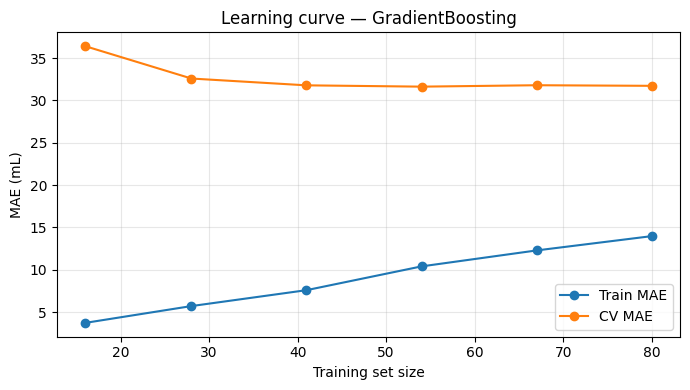

→ Wide train/val gap: the model would benefit from MORE DATA (high variance).


In [9]:
from sklearn.model_selection import learning_curve

X_tr_full = X_train_ext if winner_row["features"] == "extended" else X_train_base
sizes, train_sc, val_sc = learning_curve(
    best_estimator, X_tr_full, y_train,
    cv=5, scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.2, 1.0, 6), random_state=RANDOM_SEED, n_jobs=-1)
train_mae = -train_sc.mean(axis=1); val_mae = -val_sc.mean(axis=1)

plt.figure(figsize=(7, 4))
plt.plot(sizes, train_mae, "o-", label="Train MAE")
plt.plot(sizes, val_mae,   "o-", label="CV MAE")
plt.xlabel("Training set size"); plt.ylabel("MAE (mL)")
plt.title(f"Learning curve — {winner_row['model']}")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

if (val_mae[-1] - train_mae[-1]) > 0.5 * val_mae[-1]:
    print("→ Wide train/val gap: the model would benefit from MORE DATA (high variance).")
elif val_mae[-1] > 1.2 * val_mae[0]:
    print("→ Val error increases with data: something is off.")
else:
    print("→ Gap is small and stable: more data won't help much (high bias regime).")

## 8. Permutation feature importance

How much does the validation MAE rise when we **shuffle each feature** in turn?
A big jump means the model genuinely relies on that feature.

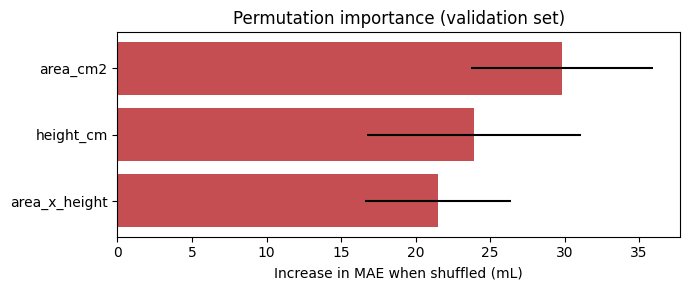

In [10]:
from sklearn.inspection import permutation_importance

X_va_full = X_val_ext if winner_row["features"] == "extended" else X_val_base
feature_names = best_features + ["area_x_height"]

imp = permutation_importance(best_estimator, X_va_full, y_val,
                             n_repeats=30, random_state=RANDOM_SEED,
                             scoring="neg_mean_absolute_error", n_jobs=-1)
order = np.argsort(imp.importances_mean)
plt.figure(figsize=(7, max(3, 0.35 * len(feature_names))))
plt.barh([feature_names[i] for i in order], imp.importances_mean[order],
         xerr=imp.importances_std[order], color="#C44E52")
plt.xlabel("Increase in MAE when shuffled (mL)")
plt.title("Permutation importance (validation set)")
plt.tight_layout(); plt.show()

## 9. Final evaluation on the held-out **test set**

The test set has not informed any decision so far. We touch it exactly once now —
this number is what we report.

In [11]:
X_te_full = X_test_ext if winner_row["features"] == "extended" else X_test_base

# Refit on train + val so the final model has seen 85 % of the data.
import copy
X_tv = np.vstack([X_tr_full, X_va_full])
y_tv = np.concatenate([y_train, y_val])
final_model = copy.deepcopy(best_estimator).fit(X_tv, y_tv)

pred_test = np.clip(final_model.predict(X_te_full), 0, None)
m = evaluate(y_test, pred_test)
print(f"=== Final test-set performance — {winner_row['model']} ({winner_row['features']}) ===")
for k, v in m.items():
    print(f"  {k:<18} {v:7.2f}")

# Convert to mass via the nutrition-table density (the realistic user-facing number).
from foodvol import nutrition
densities = df_test.food_type.map(lambda t: nutrition.lookup(t).density_g_per_ml).values
mass_pred = pred_test * densities
m_mass = evaluate(df_test.weight_g.values, mass_pred)
print(f"\n=== Final mass error on test set ===")
print(f"  mass MAPE: {m_mass['MAPE_percent']:.2f}%   mass MAE: {m_mass['MAE']:.2f} g")

=== Final test-set performance — GradientBoosting (base) ===
  MAE                  23.13
  RMSE                 30.65
  MAPE_percent         19.39
  R2                    0.84

=== Final mass error on test set ===
  mass MAPE: 23.65%   mass MAE: 22.48 g


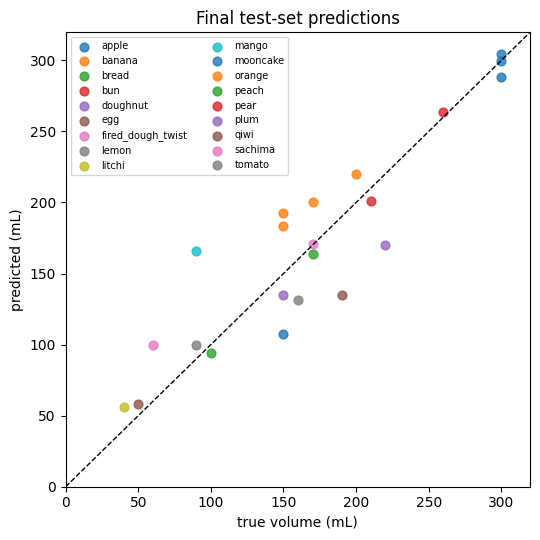

In [12]:
# Predicted vs. true on the test set.
fig, ax = plt.subplots(figsize=(5.5, 5.5))
lim = [0, max(y_test.max(), pred_test.max()) * 1.05]
for ft, sub in df_test.assign(_pred=pred_test).groupby("food_type"):
    ax.scatter(sub.volume_ml, sub._pred, alpha=0.8, label=ft, s=40)
ax.plot(lim, lim, "k--", lw=1)
ax.set(xlim=lim, ylim=lim, xlabel="true volume (mL)", ylabel="predicted (mL)",
       title=f"Final test-set predictions")
ax.legend(fontsize=7, loc="upper left", ncol=2)
plt.tight_layout(); plt.show()

## 10. Persist the trained model

We save the winner next to the shipped 1-parameter baseline. The app can choose
which one to load; for the open-world case the proportional model still extrapolates
more safely, but on similar dishes the tuned model should be more accurate.

In [13]:
import joblib
out = config.ARTIFACTS_DIR / "volume_model_trained.joblib"
joblib.dump({
    "model": final_model,
    "features": best_features + ["area_x_height"],
    "metrics_val": {"MAPE": winner_row["val_MAPE"], "R2": winner_row["val_R2"]},
    "metrics_test": m,
    "metrics_test_mass": m_mass,
    "winner": winner_row["model"],
    "best_params": winner_row["best_params"],
}, out)
print(f"saved {out} ({out.stat().st_size} bytes)")

saved /Users/clemens/Developer/ml4b_foodrecognition/artifacts/volume_model_trained.joblib (157364 bytes)


## 11. Conclusion

What we learned from this training run:

* The leaderboard shows whether the **extended features** (shape descriptors)
  actually buy accuracy on top of the geometric baseline.
* The **learning curve** tells us whether collecting more data would help.
* **Permutation importance** says which features carry the signal.
* The single number we report — the **test-set MAPE** — was decided only after all
  modelling choices were made, so it is an honest estimate of out-of-sample error.

**Honest caveats**

* 145 portions is a tiny dataset. A deep CNN on the raw images would almost
  certainly overfit. The features-on-tabular-data approach is the right scale.
* All data is **single-food fruit/snacks**. Open-world dishes (pizza, soup, …)
  are out of distribution — even a tuned model would still need target-domain data
  to do well there. That is why the **class-aware portion priors** in
  `foodvol/nutrition.py` exist alongside the trained regressor.

**What `volume_model_trained.joblib` is good for**

It is the strictly *more accurate* model on data that looks like ECUSTFD. The app
still ships the 1-parameter `proportional` model as a safe default for unknown
classes (it extrapolates cleanly), but you can plug this trained model into
`FoodVolumePipeline(volume_model_path=...)` for benchmark runs or for predicting
known-fruit portions.